# Real Nanonis Bias Spectroscopy measurement tutorial

This notebook is for real hardware testing. It does not use DemoController.

The real objects are:

- NanonisController: TCP connection plus command encoding and decoding.
- BiasSpectroscopyWorkflow: the measurement class that configures, acquires, normalizes, recovers, and restores state.

Do not use Run All. Run each cell in order and inspect its output. The acquisition cell requires typing START before it sends BiasSpectr.Start. Values use volts and SI units.

## 1. Import the real controller and workflow

Start Jupyter from the repository root or examples directory. Install the package with: python -m pip install -e .

In [1]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "nanonis").exists():
    ROOT = ROOT.parent
if not (ROOT / "src" / "nanonis").exists():
    raise RuntimeError("Start Jupyter in the repository root or examples directory")
sys.path.insert(0, str(ROOT / "src"))

from nanonis.command import NanonisController  # noqa: E402
from nanonis.workflows import (  # noqa: E402
    BiasRestoreMode,
    BiasSpectroscopyConfig,
    BiasSpectroscopySafetyPolicy,
    BiasSpectroscopySettings,
    BiasSpectroscopyWorkflow,
    NaNPolicy,
    StateRestorationError,
    estimate_acquisition_duration,
    inspect_non_finite_data,
    preflight_bias_spectroscopy,
    recover_bias_spectroscopy,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
print("Repository root:", ROOT)

Repository root: E:\Nanonis_Py\qcodes_nanonis


## 2. Configure and open the real TCP connection

Use the port configured in the Nanonis TCP command server. Your stated live-test port is 6503. This cell connects but does not start a measurement.

In [2]:
HOST = "127.0.0.1"
PORT = 6503
COMMAND_CONFIG = ROOT / "configs" / "commands"

nanonis = NanonisController(
    host=HOST,
    port=PORT,
    config_path=COMMAND_CONFIG,
    timeout=10.0,
)
nanonis.connect()
print("Connected:", nanonis.is_connected)
print("Transport state:", nanonis.transport_state)

Connected: True
Transport state: TransportState.READY


## 3. Read current hardware state

These commands are read-only. Bias.RangeGet may return Not switchable on a fixed-range controller. In that case preflight uses the explicit safety-policy bias limit instead of guessing a range.

In [3]:
bias_now = nanonis.send("Bias.Get")
feedback_now = bool(nanonis.send("ZCtrl.OnOffGet"))
setpoint_now = nanonis.send("ZCtrl.SetpntGet")
range_info = nanonis.send("Bias.RangeGet")
signal_info = nanonis.send("Signals.NamesGet")
spectroscopy_running = bool(nanonis.send("BiasSpectr.StatusGet"))

print("Bias:", bias_now, "V")
print("Z feedback enabled:", feedback_now)
print("Current setpoint:", setpoint_now, "A")
print("Bias range response:", range_info)
print("Bias Spectroscopy running:", spectroscopy_running)
print("Available signals:")
for index, name in enumerate(signal_info["signals_names"]):
    if name:
        print(f"{index:3d}: {name}")

Bias: 2.0 V
Z feedback enabled: False
Current setpoint: 5.00000006675716e-11 A
Bias range response: {'bias_ranges_size': 18, 'num_ranges': 1, 'bias_ranges': ['Not switchable'], 'bias_range_index': 0}
Bias Spectroscopy running: False
Available signals:
  0: Current (A)
  1: Input 2 (V)
  2: Input 3 (V)
  3: Input 4 (V)
  4: Input 5 (V)
  5: Input 6 (V)
  6: Input 7 (V)
  7: Input 8 (V)
  8: Input 9 (V)
  9: Input 10 (V)
 10: Input 11 (V)
 11: Input 12 (V)
 12: Input 13 (V)
 13: Input 14 (V)
 14: Input 15 (V)
 15: Input 16 (V)
 16: Input 17 (V)
 17: Input 18 (V)
 18: Input 19 (V)
 19: Input 20 (V)
 20: Input 21 (V)
 21: Input 22 (V)
 22: Input 23 (V)
 23: Input 24 (V)
 24: Bias (V)
 25: Output 2 (V)
 26: Output 3 (V)
 27: Output 4 (V)
 28: X (m)
 29: Y (m)
 30: Z (m)
 31: Output 8 (V)
 32: Output 9 (V)
 33: Output 10 (V)
 34: Output 11 (V)
 35: Output 12 (V)
 36: Output 13 (V)
 37: Output 14 (V)
 38: Output 15 (V)
 39: Output 16 (V)
 40: Output 17 (V)
 41: Output 18 (V)
 42: Output 19 (V

## 4. Define the rig-approved safety policy

These values are hard safety bounds, not measurement settings. Replace every example with a limit approved for your setup.

When Bias.RangeGet returns Not switchable, max_abs_bias is the conservative live-preflight range. DIRECT restoration performs one Bias.Set back to the original bias.

In [4]:
safety_policy = BiasSpectroscopySafetyPolicy(
    max_abs_bias=0.5,          # V: approved absolute bias bound
    max_abs_z_offset= 100e-9,   # m: approved absolute Z-offset bound
    min_slew_rate= 1e-3,        # V/s
    max_slew_rate= 10.0,        # V/s
    bias_restore_mode=BiasRestoreMode.DIRECT,
    bias_ramp=None,
    allow_zero_crossing=True,  # set False if zero crossing is forbidden
    feedback_off_during_restore=True,
)
print(safety_policy)

BiasSpectroscopySafetyPolicy(max_abs_bias=0.5, max_abs_z_offset=1e-07, min_slew_rate=0.001, max_slew_rate=10.0, bias_restore_mode=<BiasRestoreMode.DIRECT: 'direct'>, bias_ramp=None, allow_zero_crossing=True, feedback_off_during_restore=True, external_bias_restorer=None)


## 5. Define the real measurement

channel_indexes must use indexes printed by the signal-list cell. Constructing this object sends no commands.

With restore_module_settings=True, the original GUI settings return after acquisition. Set it to False only when you intentionally want the new settings to remain visible in Nanonis.

In [5]:
config = BiasSpectroscopyConfig(
    start_voltage=-0.1,
    stop_voltage=0.1,
    points=9,
    channel_indexes=(0, 1),  # verify these against the printed signal list
    sweeps=1,
    include_backward=False,
    save_individual_sweeps=False,
    z_offset=0.0,
    integration_time=0.01,
    settling_time=0.005,
    maximum_slew_rate=1.0,
    save_base_name="",
    acquisition_timeout=None,
    recovery_timeout=15.0,
    status_poll_interval=0.1,
    restore_tip_state=True,
    restore_module_settings=False,  # False leaves settings in the GUI
)
print(config)

BiasSpectroscopyConfig(start_voltage=-0.1, stop_voltage=0.1, points=9, channel_indexes=(0, 1), sweeps=1, include_backward=False, save_individual_sweeps=False, z_offset=0.0, integration_time=0.01, settling_time=0.005, maximum_slew_rate=1.0, save_base_name='', acquisition_timeout=None, recovery_timeout=15.0, status_poll_interval=0.1, restore_tip_state=True, restore_module_settings=False)


## 6. Run live preflight

This performs safety and status reads. It checks bias bounds, channel existence, Z-offset and slew policy, and whether Bias Spectroscopy is already running.

In [6]:
preflight_bias_spectroscopy(nanonis, config, safety_policy)
print("LIVE PREFLIGHT PASSED")

WARNING nanonis.workflows.spectroscopy.bias_spectroscopy: Bias.RangeGet returned 'Not switchable'; using the safety-policy bound [-0.5, 0.5] V for preflight


LIVE PREFLIGHT PASSED


## 7. Preview exact settings and timeout

This cell performs a **read-only settings preview**.

### `BiasSpectroscopySettings.snapshot(nanonis)`

This sends five getter commands: `BiasSpectr.ChsGet`, `PropsGet`, `LimitsGet`, `TimingGet`, and `AdvPropsGet`. Their responses are combined into one immutable `BiasSpectroscopySettings` object named `original_settings`. It does **not** change Nanonis settings and does **not** start a measurement. The workflow uses this snapshot as the rollback state after acquisition.

### `original_settings.patch(config)`

This creates a second, new object named `requested_settings` in Python memory. Explicit values from `config` replace the corresponding snapshot values. Optional config fields set to `None` keep their original snapshot values. It does **not** send setter commands, does **not** modify `original_settings`, and does **not** change the Nanonis GUI. Actual writes occur later inside `BiasSpectroscopyWorkflow.run(config)`.

In [7]:
# Make this standalone preview safe in a fresh kernel: read settings if needed.
if "original_settings" not in globals():
    nanonis.send("BiasSpectr.Open")
    original_settings = BiasSpectroscopySettings.snapshot(nanonis)

# Local merge only; this sends no setter commands.
requested_settings = original_settings.patch(config)
requested_settings

BiasSpectroscopySettings(channels=(0, 1), save_all=False, sweeps=1, include_backward=False, points=9, autosave=False, show_save_dialog=True, timing=BiasSpectroscopyTiming(z_averaging_time=0.05000000074505806, z_offset=0.0, initial_settling_time=0.004999999888241291, maximum_slew_rate=1.0, settling_time=0.005, integration_time=0.01, end_settling_time=0.004999999888241291, z_control_time=0.20000000298023224), advanced=BiasSpectroscopyAdvanced(reset_bias=True, z_controller_hold=True, record_final_z=False, lockin_run=False), limits=(-0.1, 0.1), parameter_names=('X (m)', 'Y (m)', 'Z (m)', 'Z offset (m)', 'Settling time (s)', 'Integration time (s)', 'Z-Ctrl hold', 'Final Z (m)'), fixed_parameter_names=('Sweep Start', 'Sweep End'))

In [8]:
nanonis.send("BiasSpectr.Open")

# READ ONLY: collect channels, properties, limits, timing, and advanced settings.
# This immutable object is the rollback baseline; no Nanonis setting changes.
original_settings = BiasSpectroscopySettings.snapshot(nanonis)
print("Captured original settings with getter commands only.")

# LOCAL ONLY: create a new requested-settings object from config overrides.
# None means preserve the snapshot value. No setter command is sent here.
requested_settings = original_settings.patch(config)
print("Computed requested settings locally; Nanonis is still unchanged.")

estimated_duration = estimate_acquisition_duration(requested_settings)
computed_timeout = estimated_duration * 1.5 + 5.0

print("Original settings:")
print(original_settings)
print()
print("Requested settings:")
print(requested_settings)
print()
print("Estimated duration:", estimated_duration, "s")
print("Computed Start timeout:", computed_timeout, "s")

Captured original settings with getter commands only.
Computed requested settings locally; Nanonis is still unchanged.
Original settings:
BiasSpectroscopySettings(channels=(0, 1), save_all=False, sweeps=1, include_backward=False, points=9, autosave=False, show_save_dialog=True, timing=BiasSpectroscopyTiming(z_averaging_time=0.05000000074505806, z_offset=0.0, initial_settling_time=0.004999999888241291, maximum_slew_rate=1.0, settling_time=0.004999999888241291, integration_time=0.009999999776482582, end_settling_time=0.004999999888241291, z_control_time=0.20000000298023224), advanced=BiasSpectroscopyAdvanced(reset_bias=True, z_controller_hold=True, record_final_z=False, lockin_run=False), limits=(-0.10000000149011612, 0.10000000149011612), parameter_names=('X (m)', 'Y (m)', 'Z (m)', 'Z offset (m)', 'Settling time (s)', 'Integration time (s)', 'Z-Ctrl hold', 'Final Z (m)'), fixed_parameter_names=('Sweep Start', 'Sweep End'))

Requested settings:
BiasSpectroscopySettings(channels=(0, 1), s

## 8. Start the real measurement

Running this cell applies settings and starts `BiasSpectr.Start`. Type exactly `START` only after reviewing the policy, config, original settings, requested settings, and duration.

### What `nan_policy` means

`nan_policy` controls only how non-finite values in the returned data matrix are handled **after the hardware acquisition has finished**. It does not change Nanonis settings or the commands sent to hardware. `NaNPolicy.ALLOW` returns the result silently, `WARN` returns it and logs NaN/Inf diagnostics, and `RAISE` raises `NonFiniteSpectroscopyDataError` while retaining the normalized result in `exc.result`. This tutorial uses `WARN` so partial or safety-aborted data is not discarded.

### What `measure.run(config)` sends to Nanonis

The workflow performs this ordered transaction:

1. **Preflight reads:** `Bias.RangeGet`, `Signals.NamesGet`, and `BiasSpectr.StatusGet`.
2. **Tip snapshot reads:** `Bias.Get`, `ZCtrl.SetpntGet`, and `ZCtrl.OnOffGet` when tip restoration is enabled.
3. **Module snapshot reads:** `BiasSpectr.Open`, followed by `ChsGet`, `PropsGet`, `LimitsGet`, `TimingGet`, and `AdvPropsGet`.
4. **Configuration writes:** `ChsSet`, `PropsSet`, `LimitsSet`, and `TimingSet`. The single configured Z offset is sent through both `PropsSet` and `TimingSet`.
5. **Readback:** the five module getters run again; this authoritative readback becomes `result.effective_settings`.
6. **Acquisition:** `BiasSpectr.Start(1, save_base_name)` is sent with the explicit or computed per-command timeout.
7. **Cleanup:** when enabled, module settings restore in the order channels, limits, timing, properties, and advanced properties; tip restoration then disables feedback, restores bias and setpoint, and restores the original feedback state last.

If `restore_module_settings=True`, the GUI returns to its original module settings when `run()` exits. If `Start` loses transport synchronization or is interrupted, the workflow reconnects, confirms or requests `BiasSpectr.Stop`, and restores only after transport and stopped-state verification.

In [9]:
confirmation = input("Type START to begin the real Bias Spectroscopy measurement: ").strip()
if confirmation != "START":
    raise RuntimeError("Measurement cancelled: confirmation was not START")

measure = BiasSpectroscopyWorkflow(
    nanonis,
    safety_policy=safety_policy,
    # WARN preserves the result and logs diagnostics for NaN/Inf values.
    # It affects returned-data handling only, not hardware commands.
    nan_policy=NaNPolicy.WARN,
)

result = None
try:
    # Execute the complete preflight -> snapshot -> configure -> readback ->
    # acquire -> normalize -> restore transaction described above.
    result = measure.run(config)
except StateRestorationError as exc:
    result = exc.result
    print("STATE RESTORATION FAILED:", exc)
    print("Original measurement error:", repr(exc.original_error))
    print("Recovery error:", repr(exc.recovery_error))
    print("Field failures:", dict(exc.failures))
    if result is None:
        raise
    print("The result was retained; save it before further hardware action.")

print("REAL MEASUREMENT FINISHED")
print("Channels:", result.channel_names)
print("Data shape:", result.data.shape)
print("Effective settings used:", result.effective_settings)
print("Acquisition duration:", result.acquisition_duration, "s")
print("Acquisition timeout used:", result.acquisition_timeout_used, "s")

WARNING nanonis.workflows.spectroscopy.bias_spectroscopy: Bias.RangeGet returned 'Not switchable'; using the safety-policy bound [-0.5, 0.5] V for preflight
INFO nanonis.workflows.state: Restoring workflow participant tip
INFO nanonis.workflows.state: Disabling Z feedback before bias restoration
INFO nanonis.workflows.state: Restoring bias directly to 2 V
INFO nanonis.workflows.state: Restoring Z-controller current setpoint to 5e-11
INFO nanonis.workflows.state: Restoring Z feedback state to False


REAL MEASUREMENT FINISHED
Channels: ('Bias calc (V)', 'Current (A)', 'Input 2 (V)')
Data shape: (3, 9)
Effective settings used: BiasSpectroscopySettings(channels=(0, 1), save_all=False, sweeps=1, include_backward=False, points=9, autosave=False, show_save_dialog=True, timing=BiasSpectroscopyTiming(z_averaging_time=0.05000000074505806, z_offset=0.0, initial_settling_time=0.004999999888241291, maximum_slew_rate=1.0, settling_time=0.004999999888241291, integration_time=0.009999999776482582, end_settling_time=0.004999999888241291, z_control_time=0.20000000298023224), advanced=BiasSpectroscopyAdvanced(reset_bias=True, z_controller_hold=True, record_final_z=False, lockin_run=False), limits=(-0.10000000149011612, 0.10000000149011612), parameter_names=('X (m)', 'Y (m)', 'Z (m)', 'Z offset (m)', 'Settling time (s)', 'Integration time (s)', 'Z-Ctrl hold', 'Final Z (m)'), fixed_parameter_names=('Sweep Start', 'Sweep End'))
Acquisition duration: 4.84400000000096 s
Acquisition timeout used: 5.69000

## 9. Inspect and plot the real result

The matrix is channel-major. The x-axis below is reconstructed from effective configured limits; it is not a measured-bias channel.

Non-finite diagnostics: NonFiniteDiagnostics(nan_count=0, inf_count=0, fully_nan_channels=(), affected_channels=())
Point count matches: True
Parameters: (SpectroscopyParameter(name='Sweep Start', value=-0.10000000149011612), SpectroscopyParameter(name='Sweep End', value=0.10000000149011612), SpectroscopyParameter(name='X (m)', value=8.496093273357985e-10), SpectroscopyParameter(name='Y (m)', value=1.334953259046756e-10), SpectroscopyParameter(name='Z (m)', value=7.500000265281415e-07), SpectroscopyParameter(name='Z offset (m)', value=0.0), SpectroscopyParameter(name='Settling time (s)', value=0.004999999888241291), SpectroscopyParameter(name='Integration time (s)', value=0.009999999776482582), SpectroscopyParameter(name='Z-Ctrl hold', value=1.0), SpectroscopyParameter(name='Final Z (m)', value=nan))
Bias calc (V) (9,) finite: 9
Current (A) (9,) finite: 9
Input 2 (V) (9,) finite: 9


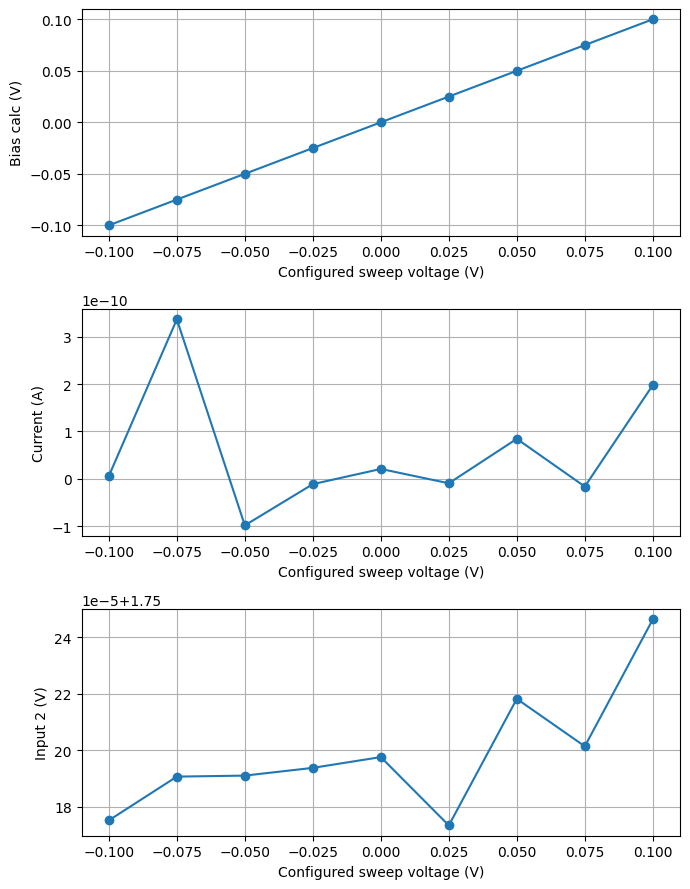

In [10]:
if result is None:
    raise RuntimeError("Run the acquisition cell first")

diagnostics = inspect_non_finite_data(result)
print("Non-finite diagnostics:", diagnostics)
print("Point count matches:", result.points_match_request)
print("Parameters:", result.parameters)
for trace in result.traces():
    print(trace.unique_name, trace.values.shape, "finite:", np.isfinite(trace.values).sum())

import matplotlib.pyplot as plt  # noqa: E402

axis = result.forward_axis().values
fig, axes = plt.subplots(
    len(result.traces()),
    1,
    figsize=(7, 3 * len(result.traces())),
    squeeze=False,
)
for plot_axis, trace in zip(axes[:, 0], result.traces()):
    plot_axis.plot(axis, trace.values, marker="o")
    plot_axis.set_xlabel("Configured sweep voltage (V)")
    plot_axis.set_ylabel(trace.name)
    plot_axis.grid(True)
fig.tight_layout()

## 10. Optionally save to QCoDeS

Install the optional dependency with: python -m pip install -e ".[qcodes]". This cell asks for separate confirmation before writing SQLite.

In [11]:
save_confirmation = input("Type SAVE to write this result to QCoDeS, or press Enter to skip: ").strip()
if save_confirmation == "SAVE":
    from qcodes.dataset import initialise_or_create_database_at, load_or_create_experiment
    from nanonis.qcodes import (
        add_bias_spectroscopy_result,
        create_bias_spectroscopy_measurement,
    )

    database_path = ROOT / "examples" / "nanonis_workflow_live.db"
    initialise_or_create_database_at(database_path)
    experiment = load_or_create_experiment(
        "Nanonis workflow live test",
        sample_name="replace-with-sample-name",
    )
    measurement, registered = create_bias_spectroscopy_measurement(experiment, result)
    with measurement.run() as datasaver:
        add_bias_spectroscopy_result(datasaver, registered, result)
        print("Saved QCoDeS run ID:", datasaver.run_id)
    print("Database:", database_path)
else:
    print("QCoDeS save skipped")

: 

: 

## 11. Optional manual settings restoration

If restore_module_settings=False, the workflow intentionally leaves new settings in the GUI. This cell can restore the snapshot captured during preview. It is unnecessary with the recommended True setting.

In [ ]:
if config.restore_module_settings:
    print("Workflow restoration was enabled; no manual restore is needed.")
else:
    restore_confirmation = input("Type RESTORE to restore original settings: ").strip()
    if restore_confirmation == "RESTORE":
        failures = original_settings.restore(nanonis)
        print("Restore failures:", failures)
    else:
        print("Original settings were not restored")

## 12. Emergency recovery only

This reconnects the TCP stream and may send BiasSpectr.Stop. Do not run it during a measurement you intend to keep running. The normal workflow invokes it automatically after a transport failure or interrupt.

In [ ]:
recovery_confirmation = input(
    "Type RECOVER to reconnect and stop Bias Spectroscopy, or press Enter to skip: "
).strip()
if recovery_confirmation == "RECOVER":
    recovery_report = recover_bias_spectroscopy(
        nanonis,
        timeout=config.recovery_timeout,
        poll_interval=config.status_poll_interval,
    )
    print(recovery_report)
else:
    print("Recovery skipped")

## 13. Disconnect

Always run this final cell when live testing is finished.

In [ ]:
nanonis.disconnect()
print("Connected:", nanonis.is_connected)
print("Transport state:", nanonis.transport_state)

Connected: False
Transport state: TransportState.DISCONNECTED
